In [1]:
import example_loader as el
import gurobipy as gp
import gurobi_utils as gu
import miplib_loader as ml
import numpy as np
import plot_utils as pu

In [2]:
# configure the backend for matplotlib
# this one should allow zoom:
%matplotlib widget
# to make that work you need: "pip install ipympl" and run "jupyter nbextension enable --py widgetsnbextension"

# this will work without the above dependencies but won't allow zoom
# %matplotlib inline

# this option may work whenever they fix bugs in mpld3
# import mpld3
# mpld3.enable_notebook()

Set parameter Username
Academic license - for non-commercial use only - expires 2023-12-04
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0
Set parameter Cuts to value 0
Set parameter Presolve to value 0
Set parameter Heuristics to value 0


Set parameter Cuts to value 0
Running model: 2D from bottom
   Relaxed 2 variables on 2D from bottom
   Negated 2 constraints on 2D from bottom
   Standardized 0 upper bounds to be constraints
   Standardized 0 lower bounds to be constraints
   Gap to target: 0.4006168083848879 : [1.22222222 2.33333333] to [1. 2.]
  Tightened y <= 2.0
   Moved: 0.3237880629013668
   Gap to target: 0.4444444444444444 : [1.44444444 2.        ] to [1. 2.]
   Moved: 0.2715376933208522
   Final score of relaxed: 2.0
   Known best score: 2


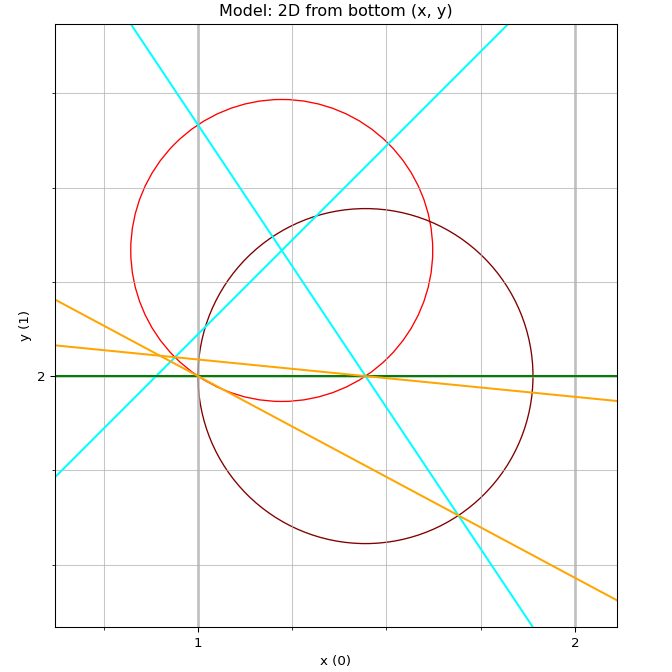

Running model: 2D from top
   Relaxed 2 variables on 2D from top
   Negated 0 constraints on 2D from top
   Standardized 0 upper bounds to be constraints
   Standardized 0 lower bounds to be constraints
   Gap to target: 0.7027283689263063 : [1.22222222 2.33333333] to [1. 3.]
  Tightened y >= 3.0
   Moved: 0.5679618342470647
   Gap to target: 0.8888888888888891 : [1.88888889 3.        ] to [1. 3.]
   Moved: 0.49424165057217245
   Final score of relaxed: 3.0
   Known best score: 3


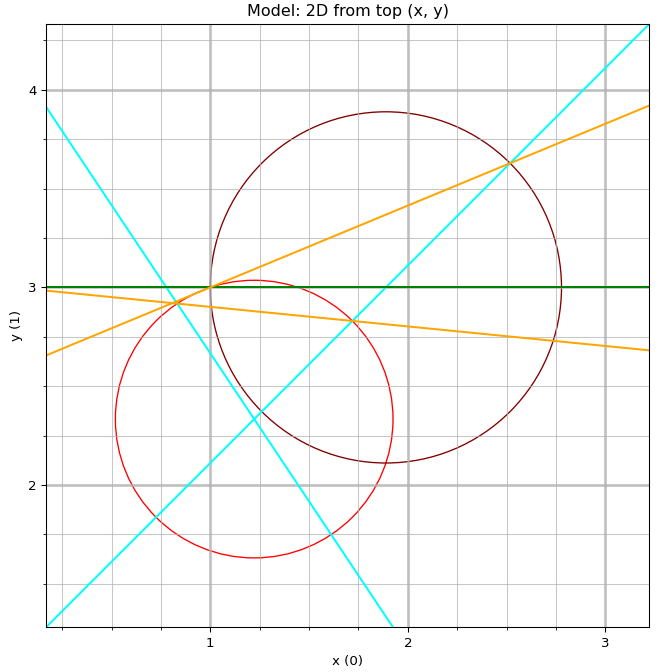

Running model: 2D from bottom (manual slacks)
   Relaxed 2 variables on 2D from bottom (manual slacks)
   Negated 0 constraints on 2D from bottom (manual slacks)
   Standardized 0 upper bounds to be constraints
   Standardized 0 lower bounds to be constraints
   Gap to target: 0.4006168083848848 : [1.22222222 2.33333333] to [1. 2.]
  Tightened y <= 2.0000000000000036


AttributeError: Unable to retrieve attribute 'VBasis'

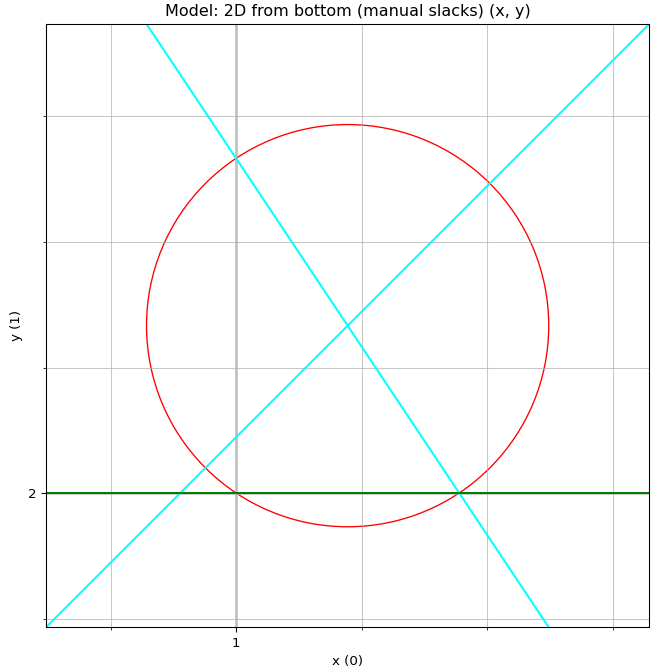

In [3]:
# A function to create cuts given a target point
def add_balas_ball_cut(relaxed: gp.Model, target, integer_vars, integer_idx, plotter, bounds_tightening=False):
    # for each column in the tableau
    # construct a sparse vector for it
    # get the length of that vector via norm1 (plus 1 if we're an int column)
    # add our cut: sum_j(x_j/a_j)
    
    norm = 2
    current = integer_vars.X
    radius = np.linalg.norm(current - target, norm)
    if radius <= relaxed.params.FeasibilityTol:
        return False  # TODO: tolerance should apply to each component individually?
    
    if len(current) < 7:
        print("   Gap to target:", radius, ":", current, "to", target)
    else:
        print("   Gap to target:", radius, "Score:", relaxed.getObjective().getValue())
    if plotter is not None:
        plotter.add_ball(radius)

    variables = relaxed.getVars()  # TODO: pass this in as it's expensive?
    constraints = relaxed.getConstrs()  # wish we didn't have to use this one
    
    basis = gu.read_basis(relaxed)
    tableau, col_to_var, negated_rows = gu.read_tableau(relaxed, basis, extra_rows=1)
    negated_vars = [basis[nr] for nr in negated_rows]
    
    # drop the rows of non-integer variables:
    to_drop = [i for i, base in enumerate(basis) if base not in integer_idx]
    tableau = np.delete(tableau, to_drop, axis=0)  # TODO: don't even bother to read them in
    basis = np.delete(basis, to_drop)

    # Conforti has negative vectors with 1 at row=col, with the rest negated.
    # However, empirically, it seems that the opposite is what we really want (gurobi-specific or ineq. standardization issue)
    int_cols = [i for i, c in enumerate(col_to_var) if c in integer_idx]
    tableau[-1, int_cols] = -1  # use our extra row to store the col==row -> 1
    lengths = np.linalg.norm(tableau, norm, axis=0)
    lengths /= radius

    if bounds_tightening:  # assuming this is only true on a feasible target
        tol = relaxed.params.IntFeasTol
        for i, base in enumerate(basis):
            all_same_sign = np.all(tableau[i, :] > -tol) or np.all(tableau[i, :] < tol)  # TODO: find a more efficient call for this
            if all_same_sign and target[integer_idx[base]] > current[integer_idx[base]]:
                new_con = relaxed.addConstr(variables[base] >= target[integer_idx[base]])
                print("  Tightened", variables[base].VarName, ">=", target[integer_idx[base]])
                if plotter is not None:
                    relaxed.update()
                    plotter.add_constraint(new_con, color='green')
            elif all_same_sign and target[integer_idx[base]] < current[integer_idx[base]]:
                new_con = relaxed.addConstr(-variables[base] >= -target[integer_idx[base]])
                print("  Tightened", variables[base].VarName, "<=", target[integer_idx[base]])
                if plotter is not None:
                    relaxed.update()
                    plotter.add_constraint(new_con, color='green')
    
    relaxed.update()
    def find_variable(index):
        if index < len(variables):
            # handle inverted variables (SCIP and Gurobi both have this silliness)
            if variables[index].VBasis == -2:  # not yet sure this is correct
                return variables[index].X - variables[index]
            assert variables[index].VBasis == -1  # not handling -3 yet
            return variables[index]
        # if only gurobi gave us access to their slack variables...
        # instead, we have to solve for it:
        cons_idx = index - len(variables)
        constraint = constraints[cons_idx]
        lhs, sense, rhs = relaxed.getRow(constraint), constraint.Sense, constraint.RHS
        if sense == '<':
             return rhs - lhs
        elif sense == '>':
            return lhs - rhs
        else:
            return 0.0  # is this right for equality constraints?
    
    summed_terms = gp.quicksum(lengths[i] * find_variable(j) for i, j in enumerate(col_to_var))
    new_con = relaxed.addConstr(summed_terms >= 1)

    def find_variable_value(index):
        if index < len(variables):
            return variables[index].X
        cons_idx = index - len(variables)
        constraint = constraints[cons_idx]
        try:
            return constraint.Slack
        except:
            return 0.0

    full_current = sum(lengths[i] * find_variable_value(j) for i, j in enumerate(col_to_var))
    print("   Moved:", (1-full_current) / np.linalg.norm(lengths, norm))
    
    # what does it mean to take a relaxed point in full space and compare only its want-to-be-integer components to another?
    if plotter is not None:
        relaxed.update()
        plotter.add_constraint(new_con)
    return True

def run_cuts_to_relaxed_sol(instances, cut_function, bounds_tightening=True, loops=8):
    for instance in instances:
        model: gp.Model = instance.as_gurobi_model()
        print("Running model:", model.ModelName)
        model.params.LogToConsole = 0
        plotter = pu.create(model)

        exact_model = model.copy()
        exact_model.update()
        exact_vars = gp.MVar.fromlist([v for v in exact_model.getVars() if v.VType != 'C'])
        z = exact_model.addMVar(exact_vars.shape, lb=-gp.GRB.INFINITY)
        exact_model.setObjective(z.sum(), gp.GRB.MINIMIZE)
        
        int_vars, int_idx = gu.relax_int_or_bin_to_continuous(model)
        if bounds_tightening:
            gu.standardize_lt_to_gt(model)
            cons1 = gu.standardize_ub_to_constr(model)
            cons2 = gu.standardize_lb_to_constr(model)
            model.update()
            for con in cons1 + cons2:
                plotter.add_constraint(con, color='cyan')

        for i in range(loops):
            model.optimize()
            if model.Status != gp.GRB.OPTIMAL:
                print("   FAILED! Status:", model.Status)
                break

            relaxed_x = int_vars.X
            ca = exact_model.addConstr(z >= exact_vars - relaxed_x)
            cb = exact_model.addConstr(z >= relaxed_x - exact_vars)
            exact_model.optimize()
            assert exact_model.Status == gp.GRB.OPTIMAL

            if not cut_function(model, exact_vars.X, int_vars, int_idx, plotter, bounds_tightening):
                print("   Final score of relaxed:", model.getObjective().getValue())
                break

            exact_model.remove(ca)
            exact_model.remove(cb)
        print("   Known best score:", instance.score if instance.known_optimum else "unknown")    
        if plotter is not None:
            plotter.render()

# test the cuts on simple examples:
run_cuts_to_relaxed_sol(list(el.get_instances().values()), add_balas_ball_cut, bounds_tightening=True)

In [ ]:
import importlib
importlib.reload(gu)

miplib_instances = ml.get_instances()
miplib_subset = [miplib_instances['air05'], miplib_instances['markshare2']]  # mas76
run_cuts_to_relaxed_sol(miplib_subset, add_balas_ball_cut)

In [7]:
import importlib
importlib.reload(gu)

import jsplib_loader as jl
jsplib_instances = jl.get_instances()
jsplib_subset = [jsplib_instances['abz5']]
run_cuts_to_relaxed_sol(jsplib_subset, add_balas_ball_cut, bounds_tightening=True, loops=20)
# jsplib_subset[0].as_gurobi_model().optimize()

Set parameter AggFill to value 10
Set parameter GomoryPasses to value 1
Running model: abz5
   Relaxed 1000 variables on abz5
   Negated 0 constraints on abz5
   Standardized 1000 upper bounds to be constraints
   Standardized 0 lower bounds to be constraints
   Gap to target: 0.7192886497123162
   Moved: 0.6927029771967528
   Gap to target: 0.7721237101561549
   Moved: 0.7519337084529613
   Gap to target: 0.7475350342230384
   Moved: 0.7279796781812415
   Gap to target: 0.7209499763060865
   Moved: 0.7107406752706437
   Gap to target: 0.8039950237328826
   Moved: 0.7936178054321789
   Gap to target: 0.7691024885709803
   Moved: 0.7660485915726973
   Gap to target: 0.7880317658263627
   Moved: 0.7674104934276718
   Gap to target: 0.7649037013530596
   Moved: 0.750011861243186
   Gap to target: 0.7202137332398938
   Moved: 0.7150980576874174
   Gap to target: 0.7593209483851207
   Moved: 0.7566113292815948
   Gap to target: 0.7201079405357095
   Moved: 0.7012715607864687
   Gap to targe

AttributeError: 'JspInstance' object has no attribute 'score'